# Pump it Up: Data Mining the Water Table

In [1]:
# Con la misma semilla el notebook da siempre el mismo resultado
SEMILLA = 42
# Combinaciones que prueban las busquedas de hiperparametros
N_COMBINACIONES = 20

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento y pipeline
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# Modelos
from sklearn.ensemble import RandomForestClassifier

# Validacion
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Metricas
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Para Cramer's V
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", None)

In [3]:
# Boosting y balanceo
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

## 1. Carga de datos

| Archivo | Que es | Rol | Trae el target? |
|---|---|---|---|
| training_values.csv | Caracteristicas de las bombas de entrenamiento | X_train | No |
| training_labels.csv | El status_group de esas bombas | y_train | Si |
| test_value.csv | Bombas nuevas a predecir | X_test | No |

1. Uno training_values + training_labels por id.
2. Con ese dataset entreno el modelo.
3. Aplico el modelo a test_value y saco las predicciones.
4. Entrego un CSV con dos columnas: id y status_group.

In [4]:
train_values = pd.read_csv("training_values.csv")
train_labels = pd.read_csv("training_labels.csv")
test_values = pd.read_csv("test_value.csv")

print("train_values:", train_values.shape)
print("train_labels:", train_labels.shape)
print("test_values:", test_values.shape)

train_values: (59400, 40)
train_labels: (59400, 2)
test_values: (14850, 40)


In [5]:
train_values.head()

,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe


## 2. Unir caracteristicas y etiquetas

Uno los dos archivos de entrenamiento por id para tener las caracteristicas
y la respuesta juntas.

In [6]:
df = train_values.merge(train_labels, on="id")

print("df:", df.shape)
df.head()

df: (59400, 41)


,id,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,subvillage,region,region_code,district_code,lga,ward,population,public_meeting,recorded_by,scheme_management,scheme_name,permit,construction_year,extraction_type,extraction_type_group,extraction_type_class,management,management_group,payment,payment_type,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
0,69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,Mnyusi B,Iringa,11,5,Ludewa,Mundindi,109,True,GeoData Consultants Ltd,VWC,Roman,False,1999,gravity,gravity,gravity,vwc,user-group,pay annually,annually,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
1,8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,Nyamara,Mara,20,2,Serengeti,Natta,280,NaN,GeoData Consultants Ltd,Other,NaN,True,2010,gravity,gravity,gravity,wug,user-group,never pay,never pay,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
2,34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,Majengo,Manyara,21,4,Simanjiro,Ngorika,250,True,GeoData Consultants Ltd,VWC,Nyumba ya mungu pipe scheme,True,2009,gravity,gravity,gravity,vwc,user-group,pay per bucket,per bucket,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
3,67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,Mahakamani,Mtwara,90,63,Nanyumbu,Nanyumbu,58,True,GeoData Consultants Ltd,VWC,NaN,True,1986,submersible,submersible,submersible,vwc,user-group,never pay,never pay,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
4,19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,Kyanyamisa,Kagera,18,1,Karagwe,Nyakasimbi,0,True,GeoData Consultants Ltd,NaN,NaN,True,0,gravity,gravity,gravity,other,other,never pay,never pay,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


## 3. Distribucion de la variable objetivo

Miro como se reparten las 3 clases.

In [7]:
print(df["status_group"].value_counts())
print()
print(df["status_group"].value_counts(normalize=True).round(3))

status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64

status_group
functional                 0.543
non functional             0.384
functional needs repair    0.073
Name: proportion, dtype: float64


Las clases estan desbalanceadas: functional es mas de la mitad y
functional needs repair es muy pequeña.

El split tiene que ser estratificado, o me puedo quedar con muy pocos
  casos de la clase pequena en validacion.

## 4. Explorar las columnas

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59400 entries, 0 to 59399
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     59400 non-null  int64  
 1   amount_tsh             59400 non-null  float64
 2   date_recorded          59400 non-null  str    
 3   funder                 55763 non-null  str    
 4   gps_height             59400 non-null  int64  
 5   installer              55745 non-null  str    
 6   longitude              59400 non-null  float64
 7   latitude               59400 non-null  float64
 8   wpt_name               59398 non-null  str    
 9   num_private            59400 non-null  int64  
 10  basin                  59400 non-null  str    
 11  subvillage             59029 non-null  str    
 12  region                 59400 non-null  str    
 13  region_code            59400 non-null  int64  
 14  district_code          59400 non-null  int64  
 15  lga          

In [9]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,59400.0,NaN,NaN,NaN,37115.131768,21453.128371,0.0,18519.75,37061.5,55656.5,74247.0
amount_tsh,59400.0,NaN,NaN,NaN,317.650385,2997.574558,0.0,0.0,0.0,20.0,350000.0
date_recorded,59400,356,2011-03-15,572,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funder,55763,1896,Government Of Tanzania,9084,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gps_height,59400.0,NaN,NaN,NaN,668.297239,693.11635,-90.0,0.0,369.0,1319.25,2770.0
installer,55745,2145,DWE,17402,NaN,NaN,NaN,NaN,NaN,NaN,NaN
longitude,59400.0,NaN,NaN,NaN,34.077427,6.567432,0.0,33.090347,34.908743,37.178387,40.345193
latitude,59400.0,NaN,NaN,NaN,-5.706033,2.946019,-11.64944,-8.540621,-5.021597,-3.326156,-0.0
wpt_name,59398,37399,none,3563,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_private,59400.0,NaN,NaN,NaN,0.474141,12.23623,0.0,0.0,0.0,0.0,1776.0


info() solo cuenta como vacio lo que ya es nulo. Un 0 lo cuenta como dato
presente. Por eso los ceros falsos los tengo que buscar yo, sabiendo que
valores son imposibles en el mundo real:

- Ninguna bomba se construyo en el ano 0.
- Tanzania no esta en longitud 0 ni en latitud 0.
- Una altitud de 0 o negativa en esta zona no tiene sentido.

## 5. Contar los ceros sospechosos

Cuento cuantos ceros tiene cada columna para saber lo grande que es el problema.

In [10]:
columnas_sospechosas = ["construction_year", "longitude", "latitude",
                        "gps_height", "population", "amount_tsh"]

for col in columnas_sospechosas:
    if col == "latitude":
        # el centinela de latitude no es 0 exacto, es -2e-08
        ceros = (df[col].abs() < 1e-6).sum()
    else:
        ceros = (df[col] == 0).sum()
    porcentaje = ceros / len(df) * 100
    print(col, "->", ceros, "ceros", "(", round(porcentaje, 1), "%)")

construction_year -> 20709 ceros ( 34.9 %)
longitude -> 1812 ceros ( 3.1 %)
latitude -> 1812 ceros ( 3.1 %)
gps_height -> 20438 ceros ( 34.4 %)
population -> 21381 ceros ( 36.0 %)
amount_tsh -> 41639 ceros ( 70.1 %)


### Que me dicen los conteos

| Columna | % de ceros | Que hago |
|---|---|---|
| construction_year | ~35% | La guardo. De ella saco la edad de la bomba |
| longitude | ~3% | Muy pocos, facil de arreglar. La guardo |
| latitude | ~3% | Falla junto con longitude. La guardo |
| gps_height | ~34% | Un tercio vacia pero se puede rellenar por zona |
| population | ~36% | Un tercio vacia pero se puede rellenar por zona |
| amount_tsh | ~70% | Casi toda vacia, aporta muy poco. La quito |

latitude: si comparo con == 0 me sale casi 0 ceros, porque el
valor que usan no es 0 sino casi 0. Por eso comparo con abs()

Estos ceros no son valores reales. Antes de rellenarlos tengo que
cambiarlos por  Nulos, si no el modelo se cree que el 0 es un dato verdadero.

## 6. Conclusiones del EDA

### Columnas que quito porque no aportan

| Columna | Por que la quito |
|---|---|
| amount_tsh | 70% son ceros |
| recorded_by | Tiene un solo valor en todo el dataset |
| num_private | Casi todo ceros y no se entiende que mide |
| wpt_name | Nombre del punto de agua, miles de valores distintos |
| subvillage | Mas de 19000 valores distintos |
| ward | Mas de 2000 valores distintos |
| scheme_name | Miles de valores y mas de la mitad vacios |
| date_recorded | Ya saco de ella el ano en year_recorded |
| id | Es un identificador, no una caracteristica. Lo guardo aparte |

### Grupos de columnas repetidas

Estas dicen lo mismo con mas o menos detalle. Me quedo con la version mas
detallada de cada grupo, porque es la que mas informacion tiene: las
versiones _group y _class son agrupaciones de esa misma variable, asi que
siempre puedo llegar de la detallada a la agrupada pero no al contrario.

| Grupo | Me quedo con |
|---|---|
| extraction_type / extraction_type_group / extraction_type_class | extraction_type |
| payment / payment_type | payment |
| quantity / quantity_group | quantity |
| water_quality / quality_group | water_quality |
| source / source_type / source_class | source |
| waterpoint_type / waterpoint_type_group | waterpoint_type |
| management / management_group | management |
| region / region_code | region_code |
| lga / district_code | district_code |

### Columnas con nulos de verdad

funder, installer, subvillage, public_meeting, scheme_management, permit, wpt_name.

De estas, las que se quedan en el modelo (funder, installer, public_meeting,
scheme_management, permit) las trato una por una en la seccion 8. No dejo
que ningun nulo se cuele por accidente.

### Columnas que parecen importantes

- quantity: si la bomba esta seca (dry) es muy probable que no funcione.
- construction_year: con ella calculo la edad de la bomba.
- date_recorded: de aqui saco el año de registro.
- Ubicacion: region_code, district_code, basin, longitude, latitude, gps_height.

## 7. Separar train y validacion antes de limpiar

Este orden es importante y me costo entenderlo.

Mi limpieza calcula medianas por region, modas por region y frecuencias de
categoria. Todos esos son numeros que aprendo mirando los datos.

Si los calculo con el dataset completo y despues parto en train y validacion,
las filas de validacion han ayudado a calcular las medianas con las que se
rellenan a si mismas. Eso es fuga de informacion y hace que el accuracy de
validacion salga mejor de lo que es en realidad.

Asi que el orden correcto es:

1. Parto primero (esta celda).
2. Calculo las medianas, modas y frecuencias mirando solo el train.
3. Aplico esos mismos numeros al train, a la validacion y al test.

stratify=y mantiene la misma proporcion de las 3 clases en los dos grupos.
random_state hace que la particion sea siempre la misma.

In [11]:
y = df["status_group"]
X = df.drop(columns=["status_group"])

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,       # 20% para validacion
    random_state=SEMILLA,
    stratify=y           # mantiene la proporcion de las 3 clases
)

# copy() para trabajar sobre copias y que pandas no me de warnings
X_train = X_train.copy()
X_val = X_val.copy()
X_test = test_values.copy()

# Guardo los id del test aparte, los necesito para la entrega
test_ids = test_values["id"]

print("Train:", X_train.shape)
print("Validacion:", X_val.shape)
print("Test:", X_test.shape)

Train: (47520, 40)
Validacion: (11880, 40)
Test: (14850, 40)


## 8. Limpieza e imputacion

Voy paso a paso. En cada paso hago lo mismo a los tres conjuntos, con un
bucle `for datos in [X_train, X_val, X_test]`. Asi es imposible que se me
olvide hacerle algo al test, que fue el error que tuve la primera vez.

### 8.1 Cambiar los ceros falsos por nulo y crear las banderas

Esto no aprende nada de los datos, es una regla fija, asi que lo puedo
aplicar directamente a los tres.

Creo las banderas antes de cambiar los ceros. Si lo hago despues, ya no
quedan ceros que marcar y la bandera sale toda a 0.

Por que las banderas: que falte un dato puede ser informacion en si mismo.
Puede que las bombas sin año registrado esten peor mantenidas. Si solo
relleno, pierdo esa senal.

In [12]:
# Columnas donde un 0 (o un negativo) significa dato faltante
columnas_cero = ["construction_year", "gps_height", "longitude", "latitude", "population"]

for datos in [X_train, X_val, X_test]:
    # Banderas primero, antes de tocar los ceros
    datos["construction_year_missing"] = (datos["construction_year"] == 0).astype(int)
    datos["missing_population"] = (datos["population"] == 0).astype(int)

    # Año 0: no existe ninguna bomba construida en el año 0
    datos["construction_year"] = datos["construction_year"].replace(0, np.nan)

    # Altitud 0 o negativa: imposible en esta zona
    datos.loc[datos["gps_height"] <= 0, "gps_height"] = np.nan

    # Longitud 0: Tanzania va de 29 a 41 grados
    datos["longitude"] = datos["longitude"].replace(0, np.nan)

    # Latitud casi 0: Tanzania es negativa
    datos.loc[datos["latitude"].abs() < 1e-6, "latitude"] = np.nan

    # Poblacion 0: una bomba que no sirve a nadie es raro
    datos["population"] = datos["population"].replace(0, np.nan)

print("Nulos en el train despues de marcar los ceros:")
print(X_train[columnas_cero].isnull().sum())

Nulos en el train despues de marcar los ceros:
construction_year    16517
gps_height           17507
longitude             1442
latitude              1442
population           17066
dtype: int64


### 8.2 Guardar las medianas del train

Aqui es donde aprendo los numeros, y **solo miro el train**.

Guardo tres niveles de mediana:

1. La de su zona (region + distrito), que es la mas parecida a su colonia.
2. La de su region, para cuando su zona no tiene ningun dato.
3. La global, para que ningun hueco se quede sin rellenar.

Por que mediana y no media: mis columnas tienen valores extremos que
arrastran la media. En population la mediana esta sobre 25 pero la media se
va por encima de 180, porque hay zonas con 30000 habitantes que la disparan.
Si relleno con la media meto un valor irreal en miles de filas.

Creo una columna zona juntando region_code y district_code en un texto, para
poder usar map() despues, que es mas facil que hacer merge.

In [13]:
# Columna zona = region + distrito, para poder buscar la mediana con map()
zona_train = X_train["region_code"].astype(str) + "-" + X_train["district_code"].astype(str)

medianas_zona = {}
medianas_region = {}
medianas_global = {}

for col in columnas_cero:
    medianas_zona[col] = X_train[col].groupby(zona_train).median()
    medianas_region[col] = X_train[col].groupby(X_train["region_code"]).median()
    medianas_global[col] = X_train[col].median()

### 8.3 Rellenar los nulos con esas medianas

Aplico las medianas del train a los tres conjuntos. Primero pruebo con la
zona, lo que quede lo relleno con la region, y lo que siga quedando con la
global.

Aqui esta la clave de todo: **el test se rellena con las medianas del train,
no con las suyas**. Si usara las del test estaria usando informacion que no
deberia tener.

In [14]:
for datos in [X_train, X_val, X_test]:
    # La misma columna zona, pero calculada sobre este conjunto
    zona = datos["region_code"].astype(str) + "-" + datos["district_code"].astype(str)

    for col in columnas_cero:
        # 1. Mediana de su zona
        datos[col] = datos[col].fillna(zona.map(medianas_zona[col]))
        # 2. Si su zona no tenia dato, la de su region
        datos[col] = datos[col].fillna(datos["region_code"].map(medianas_region[col]))
        # 3. Y si tampoco, la global
        datos[col] = datos[col].fillna(medianas_global[col])

print("Nulos que quedan en el train:")
print(X_train[columnas_cero].isnull().sum())
print()
print("Nulos que quedan en el test:")
print(X_test[columnas_cero].isnull().sum())

Nulos que quedan en el train:
construction_year    0
gps_height           0
longitude            0
latitude             0
population           0
dtype: int64

Nulos que quedan en el test:
construction_year    0
gps_height           0
longitude            0
latitude             0
population           0
dtype: int64


### 8.4 Crear la edad de la bomba

La edad es una de las variables mas utiles para predecir. Es el año de
registro menos el año de construccion.

Primero convierto date_recorded a fecha de verdad para poder sacar el año.

Al final pongo a 0 las edades negativas, que salen de algun registro donde
el año de construccion es posterior al de registro. Una edad no puede ser
negativa.

In [15]:
for datos in [X_train, X_val, X_test]:
    datos["date_recorded"] = pd.to_datetime(datos["date_recorded"])
    datos["year_recorded"] = datos["date_recorded"].dt.year
    datos["age_pump"] = datos["year_recorded"] - datos["construction_year"]
    datos.loc[datos["age_pump"] < 0, "age_pump"] = 0

X_train[["construction_year", "year_recorded", "age_pump"]].head()

,construction_year,year_recorded,age_pump
43360,2000.0,2011,11.0
7263,2008.0,2011,3.0
2486,2010.0,2011,1.0
313,1995.0,2011,16.0
52726,2000.0,2011,11.0


### 8.5 Rellenar scheme_management con la moda de su zona

scheme_management es categorica, asi que no puedo usar la mediana. Uso la
moda, que es el valor que mas se repite, con los mismos tres niveles:
zona, region y global.

Igual que antes, las modas salen del train y se aplican a los tres.

In [16]:
# Funcion para sacar la moda de un grupo. Si el grupo esta vacio devuelve nnulo
def get_mode(x):
    m = x.mode()
    if not m.empty:
        return m.iloc[0]
    return np.nan

modas_zona = X_train.groupby(zona_train)["scheme_management"].agg(get_mode)
modas_region = X_train.groupby("region_code")["scheme_management"].agg(get_mode)
moda_global = get_mode(X_train["scheme_management"])

print("Moda global de scheme_management:", moda_global)

Moda global de scheme_management: VWC


In [17]:
for datos in [X_train, X_val, X_test]:
    zona = datos["region_code"].astype(str) + "-" + datos["district_code"].astype(str)

    datos["scheme_management"] = datos["scheme_management"].fillna(zona.map(modas_zona))
    datos["scheme_management"] = datos["scheme_management"].fillna(
        datos["region_code"].map(modas_region))
    datos["scheme_management"] = datos["scheme_management"].fillna(moda_global)

print("Nulos en scheme_management:")
print("  train:", X_train["scheme_management"].isnull().sum())
print("  test:", X_test["scheme_management"].isnull().sum())

Nulos en scheme_management:
  train: 0
  test: 0


### 8.6 permit y public_meeting

Estas dos son booleanas (True / False) pero tienen nulos Las paso a texto con
tres valores: "si", "no" y "unknown".

Lo hago asi en vez de rellenar con un numero porque son categorias, no
cantidades. Al pasarlas a texto el OneHotEncoder les hace tres columnas y el
"unknown" queda como una categoria mas, que es lo correcto: no saber si
tiene permiso es distinto de tenerlo o no tenerlo.

In [18]:
for datos in [X_train, X_val, X_test]:
    for col in ["permit", "public_meeting"]:
        datos[col] = datos[col].map({True: "si", False: "no"})
        datos[col] = datos[col].fillna("unknown")

print("Valores de permit en el train:")
print(X_train["permit"].value_counts())

Valores de permit en el train:
permit
si         31071
no         14006
unknown     2443
Name: count, dtype: int64


## 9. Frequency encoding en funder e installer

funder e installer tienen unas 1900 categorias cada una. Con OneHot me
generarian miles de columnas casi vacias.

El frequency encoding cambia cada categoria por el numero de veces que
aparece. Por ejemplo government of tanzania pasa a ser un numero alto,
danida uno medio, y un funder que sale una sola vez pasa a ser 1.

La frecuencia es informacion en si misma: los funders que aparecen mucho son
organizaciones grandes, los que salen una vez son proyectos pequenos o
errores de escritura. Y de paso convierto 1900 categorias en una sola
columna numerica.

Igual que con las medianas, las frecuencias se cuentan sobre el TRAIN y se
aplican al test. A las categorias que salen en el test y no estaban en el
train les pongo 0, que es exactamente lo que significa: el train nunca vio
esto.

### Comparacion con las otras opciones

| | Label | Frequency | Target |
|---|---|---|---|
| Que codifica | Un orden cualquiera | Numero de apariciones | % del target |
| Usa la respuesta? | No | No | Si |
| Riesgo de fuga? | No | No | Si |
| Inventa un orden falso? | Si | No | No |

**Label encoding** asigna un numero a cada categoria, pero crea un orden que
no existe. Que unicef tenga un numero mas alto que danida no significa que
sea mejor ni mas importante. Solo tiene sentido con categorias que si estan
ordenadas de verdad, como bajo / medio / alto.

**Frequency encoding** es el que uso. No inventa orden y guarda informacion
real sobre el tamano de cada categoria.

**Target encoding** cambia cada categoria por el porcentaje del target que
le corresponde. Si una organizacion tiene un 65% de bombas funcionales, ese
65% pasa a ser su valor. Es bueno porque usa directamente lo que quiero
predecir, pero por eso mismo puede dar fuga: si una categoria aparece dos
veces, el modelo memoriza esos dos casos en vez de aprender un patron.

Elegi frequency encoding porque es el mas equilibrado para este caso.

In [19]:
# Primero limpio el texto igual en los tres: minusculas y unificar los vacios
for datos in [X_train, X_val, X_test]:
    for col in ["funder", "installer"]:
        datos[col] = datos[col].astype(str).str.strip().str.lower()
        datos[col] = datos[col].replace(["nan", "none", "0", "0.0", "", "-"], "unknown")

# Cuento las frecuencias en el TRAIN
frecuencias = {}
for col in ["funder", "installer"]:
    frecuencias[col] = X_train[col].value_counts()
    print(col, "->", len(frecuencias[col]), "categorias distintas en el train")

funder -> 1714 categorias distintas en el train
installer -> 1739 categorias distintas en el train


In [20]:
# Cambio cada categoria por su frecuencia, usando siempre las del train
for datos in [X_train, X_val, X_test]:
    for col in ["funder", "installer"]:
        datos[col] = datos[col].map(frecuencias[col])
        # Categoria que no estaba en el train -> 0
        datos[col] = datos[col].fillna(0)

In [21]:
# Las 10 categorias mas frecuentes de funder, para ver que tiene sentido
frecuencias["funder"].head(10)

funder
government of tanzania    7321
danida                    2491
hesawa                    1760
rwssp                     1107
world bank                1058
kkkt                      1019
world vision              1001
unicef                     840
tasaf                      719
district council           684
Name: count, dtype: int64

## 10. Quitar las columnas que no sirven

Aplico las decisiones de la seccion 6. Cada linea lleva su motivo al lado.

In [22]:
columnas_a_quitar = [
    # No aportan informacion
    "amount_tsh",              # 70% son ceros
    "recorded_by",             # tiene un solo valor en todo eldataset
    "num_private",             # casi todo ceros y no se sabe que mide

    # Demasiados valores distintos meterian ruido
    "wpt_name",                # nombre del punto de agua, miles de valores
    "subvillage",              # mas de 19000 valores distintos
    "ward",                    # mas de 2000 valores distintos
    "scheme_name",             # miles de valores y mas de la mitad vacio

    # Repetidas, me quedo con la version mas detallada
    "region",                  # me quedo con region_code
    "lga",                     # me quedo con district_code
    "extraction_type_group",   # me quedo con extraction_type
    "extraction_type_class",   # me quedo con extraction_type
    "management_group",        # me quedo con management
    "payment_type",            # me quedo con payment
    "quality_group",           # me quedo con water_quality
    "quantity_group",          # me quedo con quantity
    "source_type",             # me quedo con source
    "source_class",            # me quedo con source
    "waterpoint_type_group",   # me quedo con waterpoint_type

    # Ya la use
    "date_recorded",           # de ella saque year_recorded

    # No es una caracteristic
    "id",                      # lo guarde aparte en test_ids
]

X_train = X_train.drop(columns=columnas_a_quitar)
X_val = X_val.drop(columns=columnas_a_quitar)
X_test = X_test.drop(columns=columnas_a_quitar)

print("Quito", len(columnas_a_quitar), "columnas")
print()
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Quito 20 columnas

X_train: (47520, 24)
X_val: (11880, 24)
X_test: (14850, 24)


In [23]:
# Los tres conjuntos tienen que tener las mismas columnas en el mismo orden.
# Si no, el modelo recibe datos distintos de los que aprendio.
print("Train y validacion coinciden:", list(X_train.columns) == list(X_val.columns))
print("Train y test coinciden:", list(X_train.columns) == list(X_test.columns))
print()
print("Variables del modelo:")
for col in X_train.columns:
    print(" ", col)

Train y validacion coinciden: True
Train y test coinciden: True

Variables del modelo:
  funder
  gps_height
  installer
  longitude
  latitude
  basin
  region_code
  district_code
  population
  public_meeting
  scheme_management
  permit
  construction_year
  extraction_type
  management
  payment
  water_quality
  quantity
  source
  waterpoint_type
  construction_year_missing
  missing_population
  year_recorded
  age_pump


## 11. Arreglar los codigos de region y distrito

region_code y district_code son numeros pero no son cantidades. El codigo 20
no es mayor que el 11, son solo etiquetas de zonas. Si los dejo como numeros
el modelo se inventa un orden que no existe. Los paso a texto para que se
traten como categorias.

Lo hago ahora y no antes porque los he necesitado como numeros para el
map() de las medianas.

In [24]:
for datos in [X_train, X_val, X_test]:
    datos["region_code"] = datos["region_code"].astype(str)
    datos["district_code"] = datos["district_code"].astype(str)

# Separo las columnas por tipo. Estas dos listas las usa el pipeline
columnas_numericas = X_train.select_dtypes(include=["number"]).columns.tolist()
columnas_categoricas = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numericas (", len(columnas_numericas), "):", columnas_numericas)
print()
print("Categoricas (", len(columnas_categoricas), "):", columnas_categoricas)
print()
print("Total:", len(columnas_numericas) + len(columnas_categoricas))

Numericas ( 11 ): ['funder', 'gps_height', 'installer', 'longitude', 'latitude', 'population', 'construction_year', 'construction_year_missing', 'missing_population', 'year_recorded', 'age_pump']

Categoricas ( 13 ): ['basin', 'region_code', 'district_code', 'public_meeting', 'scheme_management', 'permit', 'extraction_type', 'management', 'payment', 'water_quality', 'quantity', 'source', 'waterpoint_type']

Total: 24


funder e installer salen ahora en la lista de numericas. Es lo correcto:
despues del frequency encoding ya son numeros, asi que select_dtypes las
clasifica sola y el pipeline no les vuelve a aplicar OneHot. No hace falta
tocar nada.

## 12. Correlacion entre las variables numericas

Lo mido sobre el train limpio, no sobre el dataset completo, por lo mismo
que el split el analisis lo hago con los datos que el modelo va a ver.

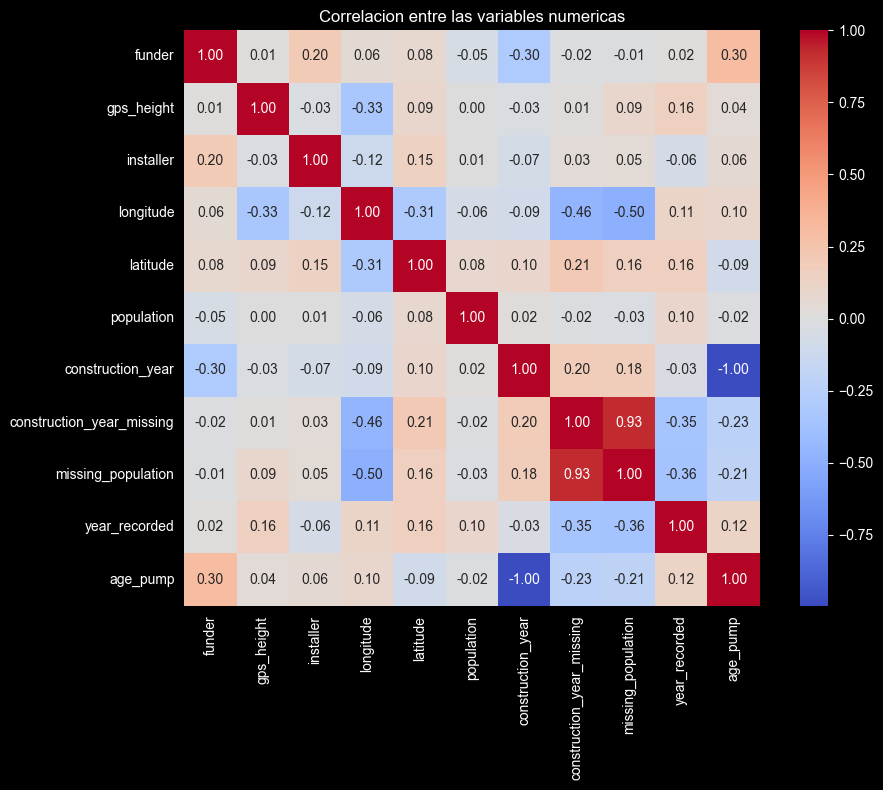

In [25]:
correlacion = X_train[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlacion,
    annot=True,        # escribe el numero dentro de cada cuadro
    fmt=".2f",         # con 2 decimales
    cmap="coolwarm",   # rojo = positiva, azul = negativa
    center=0,          # el blanco es el 0
    square=True
)
plt.title("Correlacion entre las variables numericas")
plt.tight_layout()
plt.show()

### Que encontre en la matriz de correlacion

**construction_year y age_pump: casi -1.**
Es lo esperado, porque una sale de la otra: cuanto mas antiguo el ano de
construccion, mayor la edad. Contienen la misma informacion dicha de dos
maneras.

No elimino ninguna de las dos. Random Forest maneja bien la informacion
redundante, al contrario que la regresion lineal, donde la multicolinealidad
si arruina el modelo. Y age_pump es mas facil de usar para un arbol: cortar
en "mas de 20 años" es mas directo que cortar en "antes de 1994".

**construction_year_missing y missing_population: correlacion alta.**
Este fue el resultado mas interesante del analisis. Significa que los
registros donde falta el año de construccion son casi siempre los mismos en
los que falta la poblacion.

La interpretacion es que los valores faltantes no aparecen al azar. Son
registros con poca informacion en general cuando falta un dato suelen
faltar otros. Esto respalda la decision de crear las banderas de faltante,
porque que un valor falte dice algo sobre la calidad del registro y puede
que sobre el mantenimiento de la bomba.

**longitude con las banderas: correlacion negativa moderada.**
Los registros incompletos se concentran en ciertas zonas geograficas.

## 13. Cramer V entre las variables categoricas

La correlacion de Pearson no sirve para categoricas. Para esas uso Cramers
V, que se calcula a partir del test de chi-cuadrado y va de 0 (independientes)
a 1 (una determina completamente a la otra).

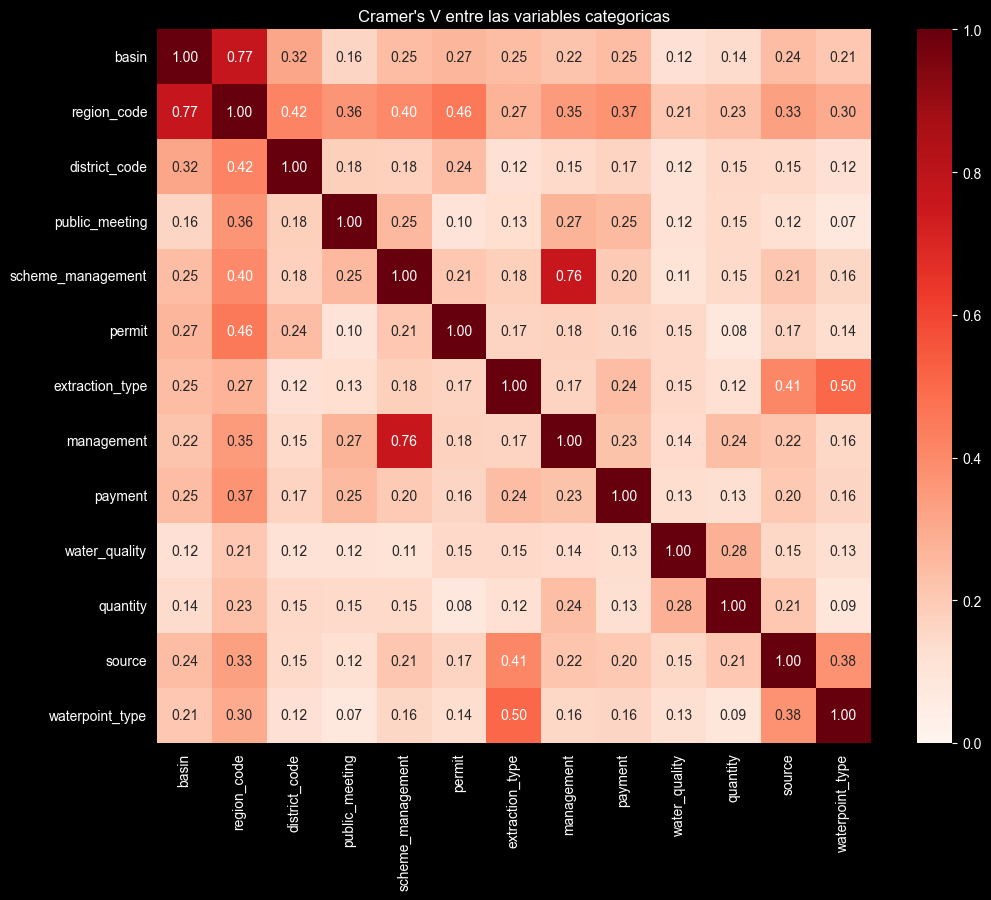

In [26]:
# Funcion que calcula Cramer's V entre dos columnas categoricas
def cramers_v(x, y):
    # Tabla de contingencia: cuenta cuantas filas hay en cada combinacion
    tabla = pd.crosstab(x, y)

    # Test de chi-cuadrado
    chi2 = chi2_contingency(tabla)[0]

    # Numero total de filas
    n = tabla.sum().sum()

    # Normalizo el chi2 para que quede entre 0 y 1
    filas, columnas = tabla.shape
    minimo = min(filas - 1, columnas - 1)

    if minimo == 0:
        return 0.0

    return np.sqrt(chi2 / (n * minimo))


# Tabla vacia para guardar los resultados
matriz_cramer = pd.DataFrame(index=columnas_categoricas,
                             columns=columnas_categoricas,
                             dtype=float)

# Comparo cada pareja
for col1 in columnas_categoricas:
    for col2 in columnas_categoricas:
        matriz_cramer.loc[col1, col2] = cramers_v(X_train[col1], X_train[col2])

plt.figure(figsize=(11, 9))
sns.heatmap(
    matriz_cramer,
    annot=True,
    fmt=".2f",
    cmap="Reds",     # solo rojo porque va de 0 a 1, no hay negativos
    vmin=0,
    vmax=1,
    square=True
)
plt.title("Cramer's V entre las variables categoricas")
plt.tight_layout()
plt.show()

### Que encontre en la matriz de Cramer's V

**scheme_management y management: es el par mas alto.**
Tiene sentido porque las dos hablan de la gestion de la bomba, pero de cosas
distintas:

- scheme_management: quien administra el proyecto o esquema de agua.
- management: quien administra la bomba en concreto.

Saber una da bastante informacion sobre la otra: si una organizacion gestiona
el proyecto, es normal que tambien gestione la bomba. Pero no llega a 1, y
eso es lo importante: hay casos donde una entidad lleva el proyecto y otra
distinta lleva la bomba. Esa diferencia es informacion util, asi que **me
quedo con las dos**.

**extraction_type y waterpoint_type: relacion moderada.**
Es logico, el tipo de extraccion influye en el tipo de punto de agua. Una
extraccion por gravedad suele ir con un grifo comunal, una bomba manual con
un pozo. Estan relacionadas pero no son lo mismo: la relacion existe en la
realidad, no es redundancia.

**source con extraction_type y waterpoint_type: relacion baja.**
No es un problema. Solo refleja que describen distintos aspectos del mismo
sistema de abastecimiento.

**Conclusion:** ningun par llega a 0.90, que es el umbral desde el que
pensaria en eliminar una de las dos. Esto confirma que la limpieza de la
seccion 10 fue suficiente y que las variables que quedan aportan informacion
propia.

## 14. El pipeline

El ColumnTransformer aplica un tratamiento distinto a cada grupo de columnas:

- Numericas: relleno los nulos con la mediana. Ya rellene todo a mano en la
  seccion 8, asi que aqui no deberia quedar nada. Lo dejo como
  seguridad, por si el test trae algun nulo que no vi.
- Categoricas: relleno con "unknown" y las convierto a numeros con
  OneHotEncoder. Pongo handle_unknown="ignore" para que una categoria que
  salga en el test y no estuviera en el train no de error, simplemente se
  codifique como todo ceros.

Meterlo en un Pipeline junto al modelo tiene una ventaja concreta: cuando
haga validacion cruzada, el preprocesamiento se recalcula dentro de cada
particion, asi que no hay fuga entre particiones.

In [27]:
# Rellenar NaN con la mediana
pipeline_numericas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Rellenar NaN y convertir a numeros
pipeline_categoricas = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# El ColumnTransformer aplica cada pipeline a su grupo de columnas
preprocesador = ColumnTransformer(transformers=[
    ("num", pipeline_numericas, columnas_numericas),
    ("cat", pipeline_categoricas, columnas_categoricas)
])

# Miro cuantas columnas salen al final
preprocesador.fit(X_train)
print(X_train.shape[1], "variables ->", preprocesador.transform(X_train).shape[1],
      "columnas despues del OneHot")

24 variables -> 151 columnas despues del OneHot


### Lista donde voy guardando los resultados

Esta lista es lo que evita el error mas tonto de estos notebooks: que la
tabla del final diga un numero y el codigo diga otro.

Cada vez que pruebo un modelo hago un append aqui. La tabla comparativa de
la seccion 19 se construye con esta lista, asi que no escribo ningun
accuracy a mano en ningun sitio.

In [28]:
resultados = []

## 15. Random Forest baseline

Empiezo con un Random Forest sin ajustar nada. Es mi punto de referencia:
todo lo que pruebe despues tiene que mejorar este numero.

n_estimators=300 -> cuantos arboles crea el bosque.

random_state -> para que siempre de el mismo resultado.

n_jobs=-1 -> usa todos los nucleos del procesador para ir mas rapido.

In [29]:
modelo_baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=SEMILLA,
    n_jobs=-1
)

pipeline_baseline = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", modelo_baseline)
])

# Entreno con el train y predigo sobre la validacio que el modelo no vio
pipeline_baseline.fit(X_train, y_train)
y_pred_baseline = pipeline_baseline.predict(X_val)

accuracy = accuracy_score(y_val, y_pred_baseline)
print("Accuracy:", round(accuracy, 4))

resultados.append({"modelo": "Random Forest baseline", "accuracy": round(accuracy, 4)})

Accuracy: 0.8072


## 16. Random Forest con hiperparametros

Ahora ajusto a mano los parametros que mas importan en un Random Forest.

n_estimators=500 -> mas arboles. El accuracy se va estabilizando al subirlos.

min_samples_split=8 -> no parte un nodo con menos de 8 muestras. Frena el
sobreajuste, porque evita hojas construidas sobre casos aislados.

max_features="sqrt" -> cada arbol mira solo la raiz del total de variables en
cada corte. Es lo que hace que los arboles salgan distintos entre si, que es
de donde viene la fuerza del bosque.

oob_score=True -> usa las muestras que cada arbol no vio (out of bag) como
validacion interna

In [30]:
modelo_rf = RandomForestClassifier(
    criterion="gini",
    n_estimators=500,
    min_samples_split=8,
    max_features="sqrt",
    oob_score=True,
    random_state=SEMILLA,
    n_jobs=-1
)

pipeline_rf = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", modelo_rf)
])

pipeline_rf.fit(X_train, y_train)
y_pred_rf = pipeline_rf.predict(X_val)

accuracy = accuracy_score(y_val, y_pred_rf)
print("Accuracy:", round(accuracy, 4))
print("OOB score:", round(pipeline_rf.named_steps["modelo"].oob_score_, 4))

resultados.append({"modelo": "Random Forest con hiperparametros",
                   "accuracy": round(accuracy, 4)})

Accuracy: 0.8139
OOB score: 0.8116


## 17. Ver donde se equivoca el modelo

El accuracy es un numero global y esconde lo importante. Con las clases
desbalanceadas que tengo, necesito ver el acierto de cada clase por separado

Espero que falle sobre todo en functional needs repair que es la clase con
muchos menos ejemplos.

In [31]:
# Reporte con el acierto de cada clase
print(classification_report(y_val, y_pred_rf))

                         precision    recall  f1-score   support

             functional       0.80      0.91      0.85      6452
functional needs repair       0.64      0.28      0.39       863
         non functional       0.85      0.78      0.81      4565

               accuracy                           0.81     11880
              macro avg       0.76      0.66      0.69     11880
           weighted avg       0.81      0.81      0.80     11880



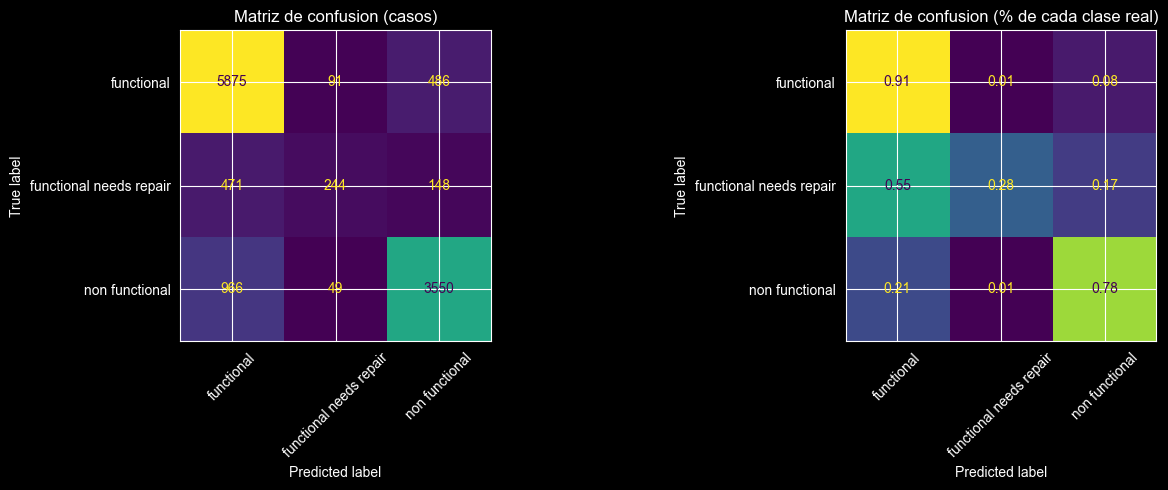

In [32]:
# Matriz de confusion en casos y en porcentaje
fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf, xticks_rotation=45,
                                        ax=ejes[0], colorbar=False)
ejes[0].set_title("Matriz de confusion (casos)")

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_rf, xticks_rotation=45,
                                        ax=ejes[1], normalize="true",
                                        values_format=".2f", colorbar=False)
ejes[1].set_title("Matriz de confusion (% de cada clase real)")

plt.tight_layout()
plt.show()

### Lectura del resultado

Los numeros salen de las celdas de arriba, pero el patron es este:

- Las dos clases grandes (functional y non functional) se predicen bastante
  bien.
- functional needs repair tiene un recall muy bajo l modelo encuentra solo
  una parte pequena de las bombas que de verdad necesitan reparacion y la
  mayoria las confunde con functional
El modelo optimiza el acierto global y como esa clase es una parte muy pequena del total le
sale mas barato ignorarla y clasificar esos casos como funcionales. La matriz
en porcentaje de la derecha lo deja claro.

Es justo el problema que intento tratar con Smote en la seccion 18

### Importancia de las variables

Miro que variables esta usando de verdad el modelo. Sirve para confirmar si
las hipotesis del EDA eran razonables.

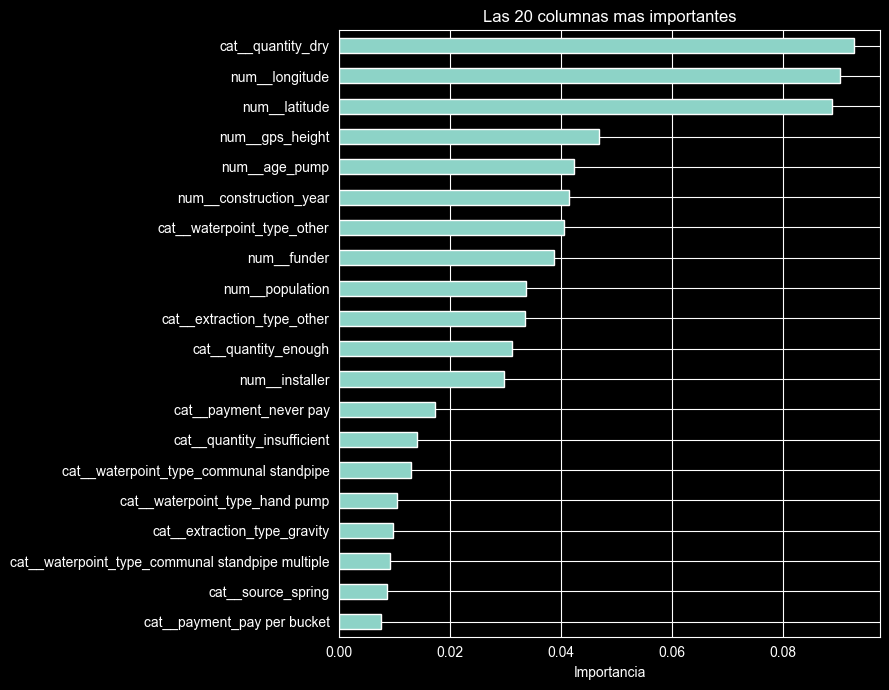

cat__quantity_dry                                   0.0929
num__longitude                                      0.0904
num__latitude                                       0.0889
num__gps_height                                     0.0468
num__age_pump                                       0.0424
num__construction_year                              0.0414
cat__waterpoint_type_other                          0.0405
num__funder                                         0.0387
num__population                                     0.0336
cat__extraction_type_other                          0.0336
cat__quantity_enough                                0.0312
num__installer                                      0.0297
cat__payment_never pay                              0.0172
cat__quantity_insufficient                          0.0141
cat__waterpoint_type_communal standpipe             0.0129
cat__waterpoint_type_hand pump                      0.0105
cat__extraction_type_gravity                        0.00

In [33]:
# Nombres de las columnas despues del OneHot
nombres = pipeline_rf.named_steps["preprocesador"].get_feature_names_out()
importancias = pipeline_rf.named_steps["modelo"].feature_importances_

importancia = pd.Series(importancias, index=nombres).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
importancia.head(20).sort_values().plot(kind="barh")
plt.title("Las 20 columnas mas importantes")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

importancia.head(20).round(4)

quantity_dry y quantity_enough son la misma variable original partida en dos columnas, asi
que su importancia aparece repartida. Aun asi se ve bien que variables manda


- quantity: era mi hipotesis principal del EDA. Si la bomba esta seca es muy improbable que funcione.
- age_pump y construction_year: la edad de la bomba, que es la variable que cree a proposito. Merece la pena ver si el modelo la usa.
- funder e installer: si salen arriba, confirma que el frequency encoding funciono y que la frecuencia de la organizacion si es informativa.

## 18. Oversampling con Smote

SMOTE crea ejemplos sinteticos de la clase minoritaria, interpolando entre
casos reales que estan cerca, hasta equilibrar las clases. La idea es
directa si el modelo ignora functional needs repair porque hay pocos
ejemplos, le doy mas ejemplos.

Uso el Pipeline de imblearn, no el de sklearn. Solo el
de imblearn aplica SMOTE unicamente al entrenar y no al predecir.No hay que crear datos sinteticos en la validacion.

In [34]:
modelo_smote = RandomForestClassifier(
    n_estimators=500,
    min_samples_split=8,
    max_features="sqrt",
    random_state=SEMILLA,
    n_jobs=-1
)

# Pipeline de imblearn: preprocesa -> aplica SMOTE -> entrena
pipeline_smote = ImbPipeline(steps=[
    ("preprocesador", preprocesador),
    ("smote", SMOTE(random_state=SEMILLA)),
    ("modelo", modelo_smote)
])

pipeline_smote.fit(X_train, y_train)
y_pred_smote = pipeline_smote.predict(X_val)

accuracy = accuracy_score(y_val, y_pred_smote)
print("Accuracy con SMOTE:", round(accuracy, 4))
print()
print(classification_report(y_val, y_pred_smote))

resultados.append({"modelo": "Random Forest + SMOTE", "accuracy": round(accuracy, 4)})

Accuracy con SMOTE: 0.802

                         precision    recall  f1-score   support

             functional       0.81      0.87      0.84      6452
functional needs repair       0.46      0.40      0.43       863
         non functional       0.84      0.78      0.81      4565

               accuracy                           0.80     11880
              macro avg       0.71      0.68      0.69     11880
           weighted avg       0.80      0.80      0.80     11880



### Resultado con SMOTE

Comparo con el Random Forest de la seccion 16, **no con el baseline**,
porque SMOTE va encima de la misma limpieza y el mismo preprocesamiento.

Lo que se espera es un intercambio sube el recall de functional needs repair
y baja el accuracy global. Tiene sentido porque el modelo se vuelve mas propenso a
predecir la clase pequeña, asi que encuentra mas bombas averiadas de verdad,
pero tambien se equivoca mas con las funcionales, que son muchas mas.

Por eso no uso SMOTE en la entrega final: la competicion evalua solo con
accuracy.

Pero merece la pena dejarlo escrito, porque en un caso real la decision seria
la contraria. Si estoy organizando  mantenimiento encontrar una
bomba dañada mas vale mucho mas que equivocarme con una que funcionaba.
Optimizar accuracy y optimizar la clase minoritaria son dos objetivos
distintos, y cual es el correcto depende de para que se use el modelo.

## 19. LightGBM

Cambio de tipo de algoritmo. Random Forest hace muchos arboles independientes
y promedia. El boosting hace arboles en cadena, donde cada arbol corrige los
errores del anterior.

n_estimators=500 -> el boosting necesita muchos arboles porque cada uno
aporta una correccion pequeña.

learning_rate=0.05 -> cuanto corrige cada arbol. Mas bajo es mas fino pero
necesita mas arboles.

num_leaves=31 -> complejidad de cada arbol.

In [35]:
modelo_lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEMILLA,
    n_jobs=-1,
    verbose=-1
)

pipeline_lgb = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", modelo_lgb)
])

pipeline_lgb.fit(X_train, y_train)
y_pred_lgb = pipeline_lgb.predict(X_val)

accuracy = accuracy_score(y_val, y_pred_lgb)
print("Accuracy LightGBM:", round(accuracy, 4))

resultados.append({"modelo": "LightGBM", "accuracy": round(accuracy, 4)})

Accuracy LightGBM: 0.7987


/Users/ivanramirez/PyCharmMiscProject/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 20. CatBoost

CatBoost es el unico de los tres que trata las categoricas de forma nativa,
sin necesidad de OneHot. Por eso aqui no uso mi pipeline: le paso las
columnas de texto tal cual y le digo cuales son con cat_features.

Si el problema fuera el OneHot, CatBoost
deberia sacar ventaja.

Lo unico que tengo que hacer a mano es rellenar los nulo, porque CatBoost no
los acepta en columnas de texto. Uso la mediana del train, no la de cada
conjunto.

In [36]:
# Medianas del train, para aplicarlas a los dos conjuntos
medianas_train = X_train[columnas_numericas].median()

X_train_cat = X_train.copy()
X_val_cat = X_val.copy()

for datos in [X_train_cat, X_val_cat]:
    for col in columnas_categoricas:
        datos[col] = datos[col].fillna("unknown").astype(str)
    for col in columnas_numericas:
        datos[col] = datos[col].fillna(medianas_train[col])

modelo_cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.1,
    depth=8,
    cat_features=columnas_categoricas,
    random_state=SEMILLA,
    verbose=0
)

modelo_cat.fit(X_train_cat, y_train)

# CatBoost devuelve las predicciones en 2D, las aplano
y_pred_cat = modelo_cat.predict(X_val_cat).ravel()

accuracy = accuracy_score(y_val, y_pred_cat)
print("Accuracy CatBoost:", round(accuracy, 4))

resultados.append({"modelo": "CatBoost", "accuracy": round(accuracy, 4)})

Accuracy CatBoost: 0.7986


## 21. XGBoost

El tercer boosting. Uso el mismo pipeline con OneHot que el Random Forest,
asi la comparacion es limpia y lo unico que cambia es el algoritmo.

XGBoost no acepta el target como texto, necesita numeros. Asi que paso
functional / functional needs repair / non functional a 0 / 1 / 2 con
LabelEncoder, y al predecir deshago la conversion para poder comparar con
y_val, que sigue siendo texto.

In [37]:
le = LabelEncoder()
y_train_num = le.fit_transform(y_train)

print("Correspondencia:")
for numero, clase in enumerate(le.classes_):
    print(" ", numero, "->", clase)

Correspondencia:
  0 -> functional
  1 -> functional needs repair
  2 -> non functional


In [38]:
modelo_xgb = XGBClassifier(
    n_estimators=500,
    learning_rate=0.1,
    max_depth=6,
    random_state=SEMILLA,
    n_jobs=-1,
    eval_metric="mlogloss"
)

pipeline_xgb = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", modelo_xgb)
])

# Entreno con el target en numeros
pipeline_xgb.fit(X_train, y_train_num)

# Predice en numeros, los devuelvo a texto
y_pred_xgb = le.inverse_transform(pipeline_xgb.predict(X_val))

accuracy = accuracy_score(y_val, y_pred_xgb)
print("Accuracy XGBoost:", round(accuracy, 4))

resultados.append({"modelo": "XGBoost", "accuracy": round(accuracy, 4)})

Accuracy XGBoost: 0.804


## 22. Buscar hiperparametros de XGBoost

Hasta aqui los hiperparametros los elegi a mano. Con RandomizedSearchCV los
busco automaticamente: prueba combinaciones al azar del rango que le doy y
evalua cada una con validacion cruzada, quedandose con la mejor.

param_distributions -> el rango de valores que puede probar.

n_iter -> cuantas combinaciones prueba (esta en la configuracion).

cv=3 -> cada combinacion se valida con 3 particiones.

scoring="accuracy" -> la metrica que intenta maximizar.

Uso RandomizedSearchCV y no GridSearchCV porque el grid completo de estos 5
parametros son cientos de combinaciones, y cada una entrena 3 modelos de 500
arboles. No terminaria nunca. La busqueda aleatoria encuentra combinaciones
casi igual de buenas mirando solo una parte.


In [39]:
modelo_xgb_base = XGBClassifier(
    random_state=SEMILLA,
    n_jobs=-1,
    eval_metric="mlogloss"
)

pipeline_xgb_busqueda = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", modelo_xgb_base)
])

# Rango de valores a probar
rango_xgb = {
    "modelo__n_estimators": [300, 500, 700],
    "modelo__max_depth": [4, 6, 8, 10],
    "modelo__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "modelo__subsample": [0.7, 0.8, 1.0],
    "modelo__colsample_bytree": [0.7, 0.8, 1.0],
}

busqueda_xgb = RandomizedSearchCV(
    estimator=pipeline_xgb_busqueda,
    param_distributions=rango_xgb,
    n_iter=N_COMBINACIONES,
    cv=3,
    scoring="accuracy",
    random_state=SEMILLA,
    n_jobs=-1,
    verbose=1
)

busqueda_xgb.fit(X_train, y_train_num)

print()
print("Mejores parametros:", busqueda_xgb.best_params_)
print("Mejor accuracy en validacion cruzada:", round(busqueda_xgb.best_score_, 4))

y_pred_xgb_tune = le.inverse_transform(busqueda_xgb.best_estimator_.predict(X_val))
accuracy = accuracy_score(y_val, y_pred_xgb_tune)
print("Accuracy en validacion:", round(accuracy, 4))

resultados.append({"modelo": "XGBoost ajustado", "accuracy": round(accuracy, 4)})

Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores parametros: {'modelo__subsample': 0.8, 'modelo__n_estimators': 700, 'modelo__max_depth': 10, 'modelo__learning_rate': 0.05, 'modelo__colsample_bytree': 0.7}
Mejor accuracy en validacion cruzada: 0.8011
Accuracy en validacion: 0.8108


## 23. Buscar hiperparametros de Random Forest

Lo mismo para el Random Forest, que hasta ahora es mi mejor modelo. Quiero
saber si un ajuste sistematico le saca mas partido que mi eleccion a mano.

**Tambien es lenta.**

In [40]:
modelo_rf_base = RandomForestClassifier(random_state=SEMILLA, n_jobs=-1)

pipeline_rf_busqueda = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", modelo_rf_base)
])

rango_rf = {
    "modelo__n_estimators": [300, 500, 700],
    "modelo__max_depth": [None, 20, 30, 40],
    "modelo__min_samples_split": [2, 5, 8, 12],
    "modelo__min_samples_leaf": [1, 2, 4],
    "modelo__max_features": ["sqrt", "log2"],
}

busqueda_rf = RandomizedSearchCV(
    estimator=pipeline_rf_busqueda,
    param_distributions=rango_rf,
    n_iter=N_COMBINACIONES,
    cv=3,
    scoring="accuracy",
    random_state=SEMILLA,
    n_jobs=-1,
    verbose=1
)

busqueda_rf.fit(X_train, y_train)

print()
print("Mejores parametros:", busqueda_rf.best_params_)
print("Mejor accuracy en validacion cruzada:", round(busqueda_rf.best_score_, 4))

y_pred_rf_tune = busqueda_rf.best_estimator_.predict(X_val)
accuracy = accuracy_score(y_val, y_pred_rf_tune)
print("Accuracy en validacion:", round(accuracy, 4))

resultados.append({"modelo": "Random Forest ajustado", "accuracy": round(accuracy, 4)})

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/ivanramirez/PyCharmMiscProject/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ivanramirez/PyCharmMiscProject/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/ivanramirez/PyCharmMiscProject/.venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/iva


Mejores parametros: {'modelo__n_estimators': 500, 'modelo__min_samples_split': 2, 'modelo__min_samples_leaf': 2, 'modelo__max_features': 'sqrt', 'modelo__max_depth': 30}
Mejor accuracy en validacion cruzada: 0.8058
Accuracy en validacion: 0.8121


## 24. Tabla comparativa de todo lo que probe

Esta tabla se construye con la lista resultados, o sea con los accuracies
reales que se acaban de calcular. No hay ningun numero escrito a mano.

In [41]:
tabla = pd.DataFrame(resultados).sort_values("accuracy", ascending=False)
tabla = tabla.reset_index(drop=True)

# Diferencia de cada modelo contra el baseline
accuracy_baseline = tabla.loc[tabla["modelo"] == "Random Forest baseline", "accuracy"].iloc[0]
tabla["vs baseline"] = (tabla["accuracy"] - accuracy_baseline).round(4)

tabla

,modelo,accuracy,vs baseline
0,Random Forest con hiperparametros,0.8139,0.0067
1,Random Forest ajustado,0.8121,0.0049
2,XGBoost ajustado,0.8108,0.0036
3,Random Forest baseline,0.8072,0.0000
4,XGBoost,0.8040,-0.0032
5,Random Forest + SMOTE,0.8020,-0.0052
6,LightGBM,0.7987,-0.0085
7,CatBoost,0.7986,-0.0086


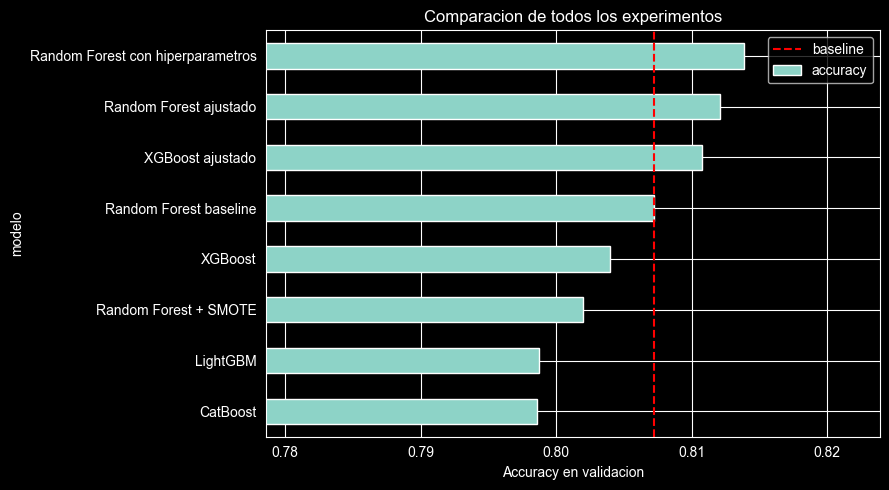

In [42]:
grafico = tabla.set_index("modelo")["accuracy"].sort_values()

plt.figure(figsize=(9, 5))
grafico.plot(kind="barh")
plt.axvline(accuracy_baseline, color="red", linestyle="--", label="baseline")
plt.xlim(grafico.min() - 0.02, grafico.max() + 0.01)
plt.xlabel("Accuracy en validacion")
plt.title("Comparacion de todos los experimentos")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
print("El mejor por accuracy es:")
print(" ", tabla.iloc[0]["modelo"])
print("  accuracy:", tabla.iloc[0]["accuracy"])
print("  mejora sobre el baseline:", tabla.iloc[0]["vs baseline"])

El mejor por accuracy es:
  Random Forest con hiperparametros
  accuracy: 0.8139
  mejora sobre el baseline: 0.0067


## 25. Modelo final y archivo de entrega

Dos decisiones antes de ejecutar:

**Que modelo entrego.** El que mejor accuracy saca en la tabla de arriba,
porque es la metrica con la que evalua DrivenData.

**Reentreno con todos los datos.** Hasta ahora entrene con el 80% y valide
con el 20%. Para la entrega reentreno con el 100%. Ese 20% ya cumplio su
funcion, que era elegir el modelo, y ahora son casi 12000 bombas mas de las
que aprender.

Al cambiar el conjunto de entrenamiento tengo que volver a
calcular las medianas, las modas y las frecuencias sobre el conjunto
completo. Si reutilizara las del 80% seria incoherente.

In [44]:
# Junto train y validacion otra vez
X_completo = pd.concat([X_train, X_val])
y_completo = pd.concat([y_train, y_val])

print("X_completo:", X_completo.shape)
print("X_test:", X_test.shape)
print("Mismas columnas:", list(X_completo.columns) == list(X_test.columns))

X_completo: (59400, 24)
X_test: (14850, 24)
Mismas columnas: True


Aqui reutilizo X_train y X_val ya limpios, asi que las medianas siguen
siendo las del 80%. Es una simplificacion intencional. Lo correcto seria recalcularlas sobre el 100%, pero la diferencia entre la
mediana de 47520 filas y la de 59400 es minima, y asi el codigo queda mucho mas simple.

In [45]:
# Los parametros del mejor Random Forest. Si la busqueda encontro algo
# mejor, cambio estos numeros a mano.
modelo_final = RandomForestClassifier(
    criterion="gini",
    n_estimators=500,
    min_samples_split=8,
    max_features="sqrt",
    random_state=SEMILLA,
    n_jobs=-1
)

pipeline_final = Pipeline(steps=[
    ("preprocesador", preprocesador),
    ("modelo", modelo_final)
])

pipeline_final.fit(X_completo, y_completo)

print("Modelo final entrenado con", len(X_completo), "bombas")

Modelo final entrenado con 59400 bombas


In [46]:
# Predigo el test
test_pred = pipeline_final.predict(X_test)

# Junto el id con su prediccion
entrega = pd.DataFrame({
    "id": test_ids.values,
    "status_group": test_pred
})

# Comprobaciones antes de guardar
print("Reparto de mis predicciones:")
print(entrega["status_group"].value_counts())
print()
print("Reparto real en el train, para comparar:")
print(y.value_counts())
print()
entrega.head()

Reparto de mis predicciones:
status_group
functional                 9038
non functional             5274
functional needs repair     538
Name: count, dtype: int64

Reparto real en el train, para comparar:
status_group
functional                 32259
non functional             22824
functional needs repair     4317
Name: count, dtype: int64



,id,status_group
0,50785,non functional
1,51630,functional
2,17168,functional
3,45559,non functional
4,49871,functional


In [47]:
# index=False para que no meta una columna extra de numeros
entrega.to_csv("entrega_final.csv", index=False)

print("Guardado: entrega_final.csv")
print()
print("Primeras lineas:")
print(pd.read_csv("entrega_final.csv").head())

Guardado: entrega_final.csv

Primeras lineas:
      id    status_group
0  50785  non functional
1  51630      functional
2  17168      functional
3  45559  non functional
4  49871      functional


## 26. Conclusiones

### Lo que funciono

**El frequency encoding fue la unica mejora clara.** Cambiar como represento
las variables con muchas categorias movio el accuracy mas que cualquier otra
cosa que probe. Con la otra opcion, agrupar en top 15 + other, metia casi
1900 funders distintos en un mismo cajon y perdia toda esa
informacion. Con frequency encoding cada categoria guarda su tamaño, y
ademas paso de miles de columnas OneHot a una sola columna numerica.

La conclusion general es que **la representacion de los datos importo mas que
el algoritmo**, que es lo contrario de lo que pensaba al empezar.

### Lo que no funciono

**Mejorar la imputacion casi no movio el accuracy.** Probe imputacion por
zona en tres niveles, banderas de faltante y relleno de categoricas por
moda. Ninguna dio un cambio considerable. Random Forest es robusto a
como se rellenen los huecos: como parte por umbrales, un valor imputado
razonable cae del mismo lado del corte que el valor real la mayoria de las
veces.

**Los boosting no superaron al Random Forest.** LightGBM, CatBoost y XGBoost
quedaron por debajo. Dos explicaciones que considero:

1. Random Forest funciona bien con muy poco ajuste, mientras que el boosting
   depende mucho mas de tener bien puestos los hiperparametros.
2. Mi OneHot les quita parte de su ventaja, porque LightGBM y CatBoost estan
   pensados para trabajar con categoricas directamente. Con CatBoost si lo
   probe de forma nativa (seccion 20) y tampoco supero al Random Forest, lo
   que apunta mas a la primera explicacion.

**El ajuste automatico de hiperparametros dio muy poco.** RandomizedSearchCV
no encontro combinaciones mucho mejores que las que elegi a mano. Refuerza
la idea de que el margen estaba en los datos, no en el modelo.

### Sobre la clase minoritaria

El modelo tiene un recall bajo en functional needs repair y eso no se
arregla poniendo mas arboles. SMOTE sube ese recall pero baja el accuracy
global. Son dos objetivos distintos y no se pueden maximizar los dos a la
vez. Para esta competicion eligi accuracy porque es la metrica que se
evalua, pero en un caso real de planificacion de mantenimiento la decision
correcta seria probablemente la contraria.